<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/Medical_Image_Segmentation_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Image Segmentation with U-Net
## Senior Data Science Portfolio Project

This self-contained notebook builds an end-to-end binary medical-image segmentation pipeline in PyTorch.

**Includes:** synthetic medical-style data generation, EDA, augmentation, U-Net from scratch, Dice+BCE loss, training, evaluation, visualization, checkpointing, inference, error analysis, portfolio summary, and interview questions.

> Educational portfolio project only. It is not a clinical diagnostic system.

## 1. Problem statement

Medical image segmentation classifies every pixel as background or a region of interest. Typical applications include lesions, tumors, polyps, organs, and abnormal tissue.

The project workflow is:

1. Build paired images and masks.
2. inspect image and mask quality.
3. train a U-Net.
4. measure Dice and IoU.
5. inspect prediction failures.
6. save the model for reproducible inference.

## 2. Evaluation metrics

**Dice coefficient**

\[
Dice = \frac{2|P \cap G|}{|P|+|G|}
\]

**Intersection over Union**

\[
IoU = \frac{|P \cap G|}{|P \cup G|}
\]

These overlap metrics are more informative than raw accuracy when the foreground occupies a small part of the image.

In [1]:
# Uncomment in a fresh environment:
# !pip install torch torchvision numpy pandas matplotlib pillow

In [2]:
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cpu
Device: cpu


In [3]:
CONFIG = {
    "num_samples": 240,
    "image_size": 128,
    "batch_size": 8,
    "epochs": 4,
    "learning_rate": 1e-3,
    "validation_fraction": 0.20,
    "test_fraction": 0.10,
    "threshold": 0.50,
    "base_channels": 16,
}

DATA_ROOT = Path("synthetic_medical_segmentation_data")
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"
MODEL_PATH = Path("unet_medical_segmentation.pt")

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)
CONFIG

{'num_samples': 240,
 'image_size': 128,
 'batch_size': 8,
 'epochs': 4,
 'learning_rate': 0.001,
 'validation_fraction': 0.2,
 'test_fraction': 0.1,
 'threshold': 0.5,
 'base_channels': 16}

## 3. Synthetic medical-style data

For portability, the notebook generates original images with textured backgrounds and lesion-like elliptical regions. Every image has a matching binary mask. Replace this section with a public dataset such as Kvasir-SEG, CVC-ClinicDB, BUSI, ISIC, or SIIM-ACR for a real research exercise.

In [4]:
def create_synthetic_case(index: int, image_size: int = 128) -> Tuple[Image.Image, Image.Image]:
    rng = np.random.default_rng(SEED + index)
    yy, xx = np.mgrid[0:image_size, 0:image_size]
    gradient = 45 + 18 * (xx / image_size) + 12 * (yy / image_size)
    texture = rng.normal(0, 8, size=(image_size, image_size))
    base = np.clip(gradient + texture, 0, 255).astype(np.uint8)

    rgb = np.stack([
        np.clip(base + rng.integers(20, 45), 0, 255),
        np.clip(base + rng.integers(0, 20), 0, 255),
        np.clip(base - rng.integers(0, 15), 0, 255),
    ], axis=-1).astype(np.uint8)

    image = Image.fromarray(rgb, mode="RGB")
    mask = Image.new("L", (image_size, image_size), 0)
    image_draw = ImageDraw.Draw(image, "RGBA")
    mask_draw = ImageDraw.Draw(mask)

    for _ in range(int(rng.integers(1, 4))):
        width = int(rng.integers(image_size // 7, image_size // 3))
        height = int(rng.integers(image_size // 7, image_size // 3))
        x1 = int(rng.integers(8, image_size - width - 8))
        y1 = int(rng.integers(8, image_size - height - 8))
        x2, y2 = x1 + width, y1 + height

        color = (
            int(rng.integers(120, 210)),
            int(rng.integers(25, 80)),
            int(rng.integers(35, 90)),
            int(rng.integers(150, 220)),
        )
        image_draw.ellipse((x1, y1, x2, y2), fill=color)
        mask_draw.ellipse((x1, y1, x2, y2), fill=255)

    image = image.filter(ImageFilter.GaussianBlur(radius=float(rng.uniform(0.4, 1.2))))
    return image, mask


def generate_dataset(num_samples: int, image_size: int) -> pd.DataFrame:
    records: List[Dict[str, object]] = []
    for index in range(num_samples):
        image_path = IMAGE_DIR / ("image_%04d.png" % index)
        mask_path = MASK_DIR / ("mask_%04d.png" % index)

        if not image_path.exists() or not mask_path.exists():
            image, mask = create_synthetic_case(index, image_size)
            image.save(image_path)
            mask.save(mask_path)

        mask_array = np.asarray(Image.open(mask_path), dtype=np.float32) / 255.0
        records.append({
            "sample_id": index,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "mask_fraction": float(mask_array.mean()),
        })
    return pd.DataFrame(records)


metadata = generate_dataset(CONFIG["num_samples"], CONFIG["image_size"])
metadata.head()

,sample_id,image_path,mask_path,mask_fraction
0,0,synthetic_medical_segmentation_data/images/ima...,synthetic_medical_segmentation_data/masks/mask...,0.067444
1,1,synthetic_medical_segmentation_data/images/ima...,synthetic_medical_segmentation_data/masks/mask...,0.070251
2,2,synthetic_medical_segmentation_data/images/ima...,synthetic_medical_segmentation_data/masks/mask...,0.080994
3,3,synthetic_medical_segmentation_data/images/ima...,synthetic_medical_segmentation_data/masks/mask...,0.144958
4,4,synthetic_medical_segmentation_data/images/ima...,synthetic_medical_segmentation_data/masks/mask...,0.115723


## 4. Exploratory data analysis

       sample_id  mask_fraction
count  240.00000     240.000000
mean   119.50000       0.085366
std     69.42622       0.039036
min      0.00000       0.021301
25%     59.75000       0.052383
50%    119.50000       0.082123
75%    179.25000       0.115219
max    239.00000       0.180481


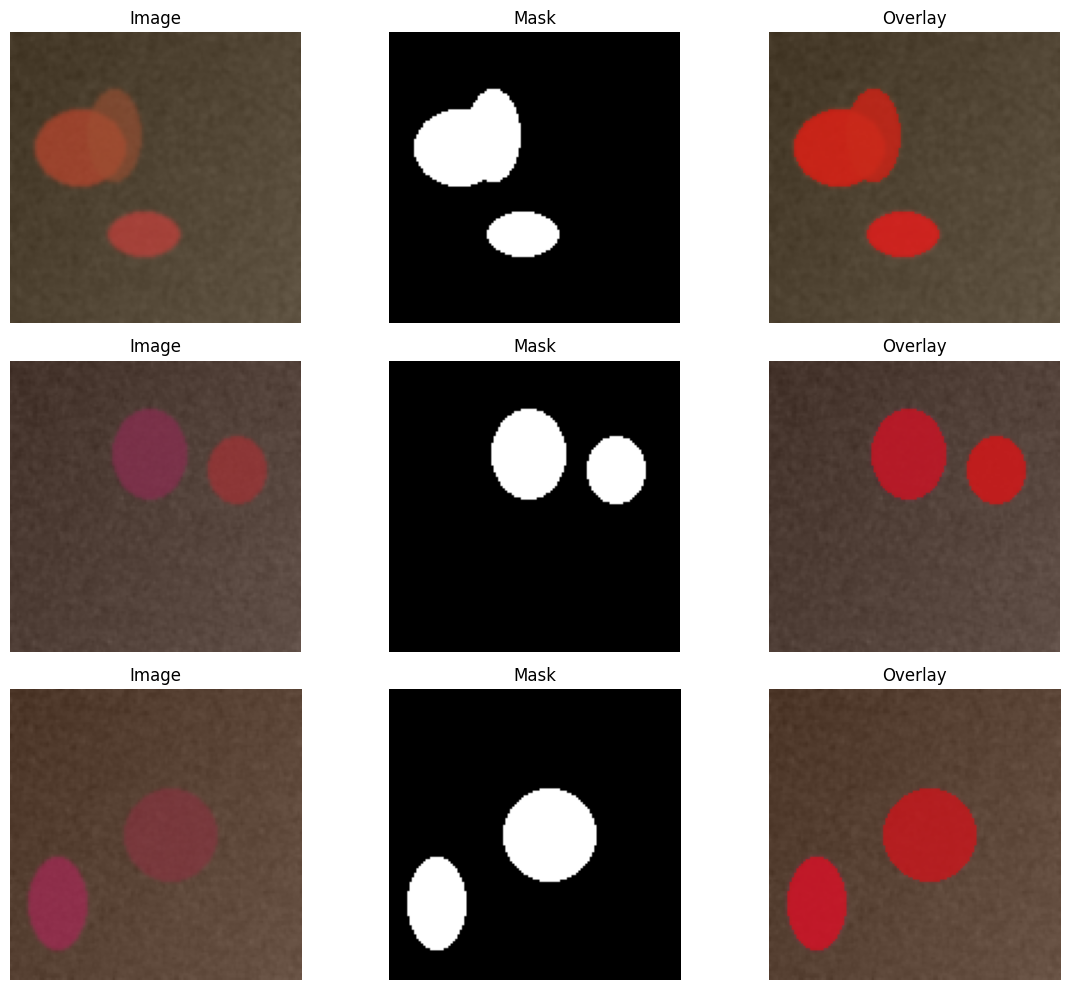

In [5]:
print(metadata.describe())

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for row in range(3):
    sample = metadata.sample(1, random_state=SEED + row).iloc[0]
    image = np.asarray(Image.open(sample["image_path"]).convert("RGB"))
    mask = np.asarray(Image.open(sample["mask_path"]).convert("L"))

    overlay = image.copy()
    red = np.zeros_like(image)
    red[..., 0] = 255
    alpha = (mask.astype(np.float32) / 255.0)[..., None] * 0.45
    overlay = (overlay * (1 - alpha) + red * alpha).astype(np.uint8)

    axes[row, 0].imshow(image); axes[row, 0].set_title("Image")
    axes[row, 1].imshow(mask, cmap="gray"); axes[row, 1].set_title("Mask")
    axes[row, 2].imshow(overlay); axes[row, 2].set_title("Overlay")
    for col in range(3): axes[row, col].axis("off")

plt.tight_layout()
plt.show()

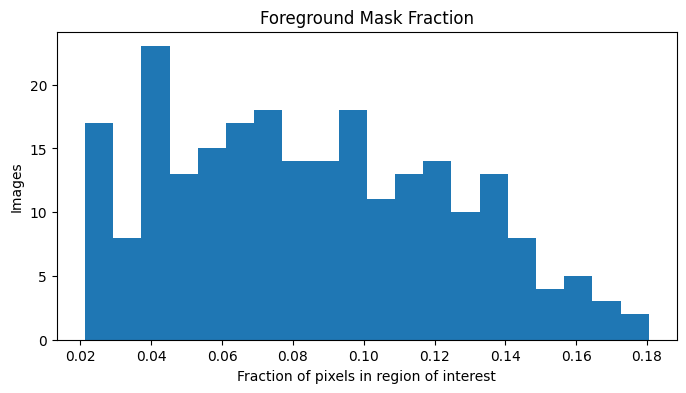

Empty masks: 0
Average foreground fraction: 0.0854


In [6]:
plt.figure(figsize=(8, 4))
plt.hist(metadata["mask_fraction"], bins=20)
plt.title("Foreground Mask Fraction")
plt.xlabel("Fraction of pixels in region of interest")
plt.ylabel("Images")
plt.show()

print("Empty masks:", int((metadata["mask_fraction"] == 0).sum()))
print("Average foreground fraction:", round(metadata["mask_fraction"].mean(), 4))

## 5. PyTorch dataset and paired augmentation

In [7]:
class MedicalSegmentationDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, augment: bool = False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.dataframe.iloc[index]
        image = np.asarray(Image.open(row["image_path"]).convert("RGB"), dtype=np.float32) / 255.0
        mask = np.asarray(Image.open(row["mask_path"]).convert("L"), dtype=np.float32) / 255.0
        mask = (mask >= 0.5).astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                image, mask = np.flip(image, 1).copy(), np.flip(mask, 1).copy()
            if random.random() < 0.5:
                image, mask = np.flip(image, 0).copy(), np.flip(mask, 0).copy()
            k = random.randint(0, 3)
            if k:
                image, mask = np.rot90(image, k).copy(), np.rot90(mask, k).copy()

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
        return image_tensor, mask_tensor

In [8]:
indices = np.arange(len(metadata))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

test_size = int(len(indices) * CONFIG["test_fraction"])
val_size = int(len(indices) * CONFIG["validation_fraction"])

test_ids = indices[:test_size]
val_ids = indices[test_size:test_size + val_size]
train_ids = indices[test_size + val_size:]

train_df = metadata.iloc[train_ids].reset_index(drop=True)
val_df = metadata.iloc[val_ids].reset_index(drop=True)
test_df = metadata.iloc[test_ids].reset_index(drop=True)

train_dataset = MedicalSegmentationDataset(train_df, augment=True)
val_dataset = MedicalSegmentationDataset(val_df)
test_dataset = MedicalSegmentationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

print("Train:", len(train_dataset), "Validation:", len(val_dataset), "Test:", len(test_dataset))

Train: 168 Validation: 48 Test: 24


## 6. U-Net architecture

U-Net combines an encoder, bottleneck, decoder, and skip connections. The encoder learns increasingly abstract features. The decoder restores spatial resolution. Skip connections preserve boundary and localization information.

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base_channels: int = 16):
        super().__init__()
        features = [base_channels, base_channels * 2, base_channels * 4, base_channels * 8]
        self.encoders, self.pools = nn.ModuleList(), nn.ModuleList()
        current = in_channels

        for feature in features:
            self.encoders.append(DoubleConv(current, feature))
            self.pools.append(nn.MaxPool2d(2))
            current = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.upconvs, self.decoders = nn.ModuleList(), nn.ModuleList()
        current = features[-1] * 2

        for feature in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(current, feature, 2, 2))
            self.decoders.append(DoubleConv(feature * 2, feature))
            current = feature

        self.output_layer = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skips = []
        for encoder, pool in zip(self.encoders, self.pools):
            x = encoder(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for upconv, decoder, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = decoder(torch.cat([skip, x], dim=1))

        return self.output_layer(x)


model = UNet(base_channels=CONFIG["base_channels"]).to(DEVICE)
images, masks = next(iter(train_loader))
with torch.no_grad():
    outputs = model(images.to(DEVICE))

print("Input:", tuple(images.shape))
print("Masks:", tuple(masks.shape))
print("Output:", tuple(outputs.shape))
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Input: (8, 3, 128, 128)
Masks: (8, 1, 128, 128)
Output: (8, 1, 128, 128)
Parameters: 1942577


## 7. Combined Dice and binary cross-entropy loss

In [10]:
def soft_dice(logits: torch.Tensor, targets: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:
    probabilities = torch.sigmoid(logits).view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probabilities * targets).sum(dim=1)
    return ((2 * intersection + smooth) / (probabilities.sum(dim=1) + targets.sum(dim=1) + smooth)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return self.bce(logits, targets) + (1 - soft_dice(logits, targets))


criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

## 8. Metrics

In [11]:
def calculate_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5) -> Dict[str, float]:
    predictions = (torch.sigmoid(logits) >= threshold).float().view(-1)
    targets = targets.view(-1)
    eps = 1e-7

    tp = (predictions * targets).sum()
    fp = (predictions * (1 - targets)).sum()
    fn = ((1 - predictions) * targets).sum()
    tn = ((1 - predictions) * (1 - targets)).sum()

    return {
        "dice": float(((2 * tp + eps) / (2 * tp + fp + fn + eps)).item()),
        "iou": float(((tp + eps) / (tp + fp + fn + eps)).item()),
        "precision": float(((tp + eps) / (tp + fp + eps)).item()),
        "recall": float(((tp + eps) / (tp + fn + eps)).item()),
        "pixel_accuracy": float(((tp + tn + eps) / (tp + tn + fp + fn + eps)).item()),
    }

## 9. Training and validation

In [12]:
def run_epoch(model, dataloader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    losses, rows = [], []

    for images, masks in dataloader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, masks)
            if training:
                loss.backward()
                optimizer.step()

        losses.append(float(loss.item()))
        rows.append(calculate_metrics(logits.detach(), masks.detach()))

    metrics = pd.DataFrame(rows).mean().to_dict()
    metrics["loss"] = float(np.mean(losses))
    return metrics

In [13]:
history = []
for epoch in range(1, CONFIG["epochs"] + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_dice": train_metrics["dice"],
        "val_dice": val_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_iou": val_metrics["iou"],
    }
    history.append(row)
    print("Epoch %d/%d | train loss %.4f | val loss %.4f | val Dice %.4f | val IoU %.4f"
          % (epoch, CONFIG["epochs"], row["train_loss"], row["val_loss"], row["val_dice"], row["val_iou"]))

history_df = pd.DataFrame(history)
history_df

Epoch 1/4 | train loss 1.2203 | val loss 1.3159 | val Dice 0.2201 | val IoU 0.1249
Epoch 2/4 | train loss 1.0327 | val loss 0.9907 | val Dice 0.8689 | val IoU 0.7705
Epoch 3/4 | train loss 0.9263 | val loss 0.8502 | val Dice 0.9397 | val IoU 0.8913
Epoch 4/4 | train loss 0.8404 | val loss 0.8154 | val Dice 0.9156 | val IoU 0.8527


,epoch,train_loss,val_loss,train_dice,val_dice,train_iou,val_iou
0,1,1.220337,1.315939,0.787462,0.220078,0.680503,0.124861
1,2,1.032745,0.990677,0.903760,0.868940,0.827671,0.770456
2,3,0.926305,0.850198,0.935646,0.939702,0.881207,0.891279
3,4,0.840441,0.815394,0.946425,0.915554,0.901726,0.852677


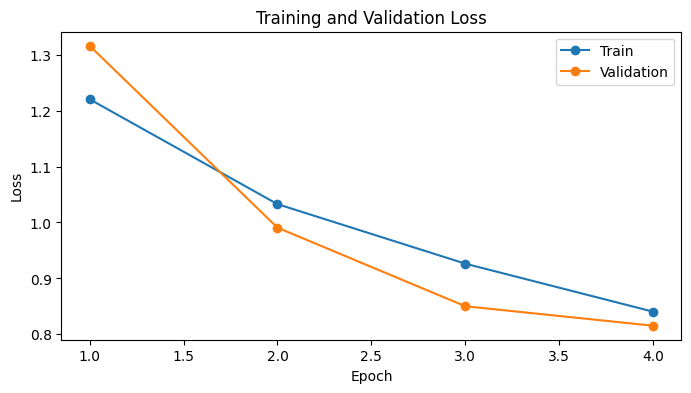

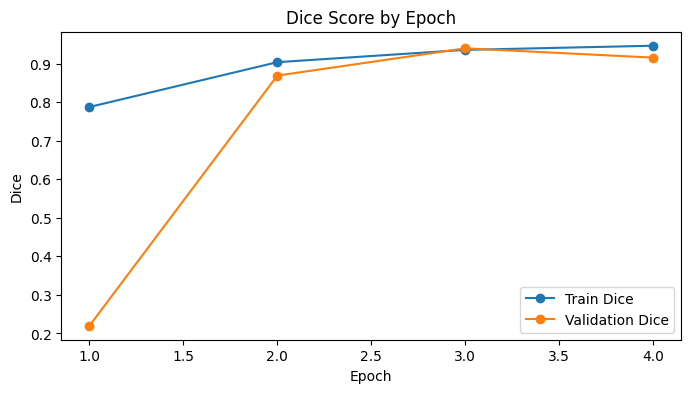

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training and Validation Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_dice"], marker="o", label="Train Dice")
plt.plot(history_df["epoch"], history_df["val_dice"], marker="o", label="Validation Dice")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice Score by Epoch"); plt.legend(); plt.show()

## 10. Test-set evaluation

In [15]:
test_metrics = run_epoch(model, test_loader, criterion)
pd.Series(test_metrics, name="test_metrics")

,test_metrics
dice,0.910575
iou,0.849546
precision,0.863763
recall,0.984629
pixel_accuracy,0.982999
loss,0.794238


## 11. Prediction visualization and error analysis

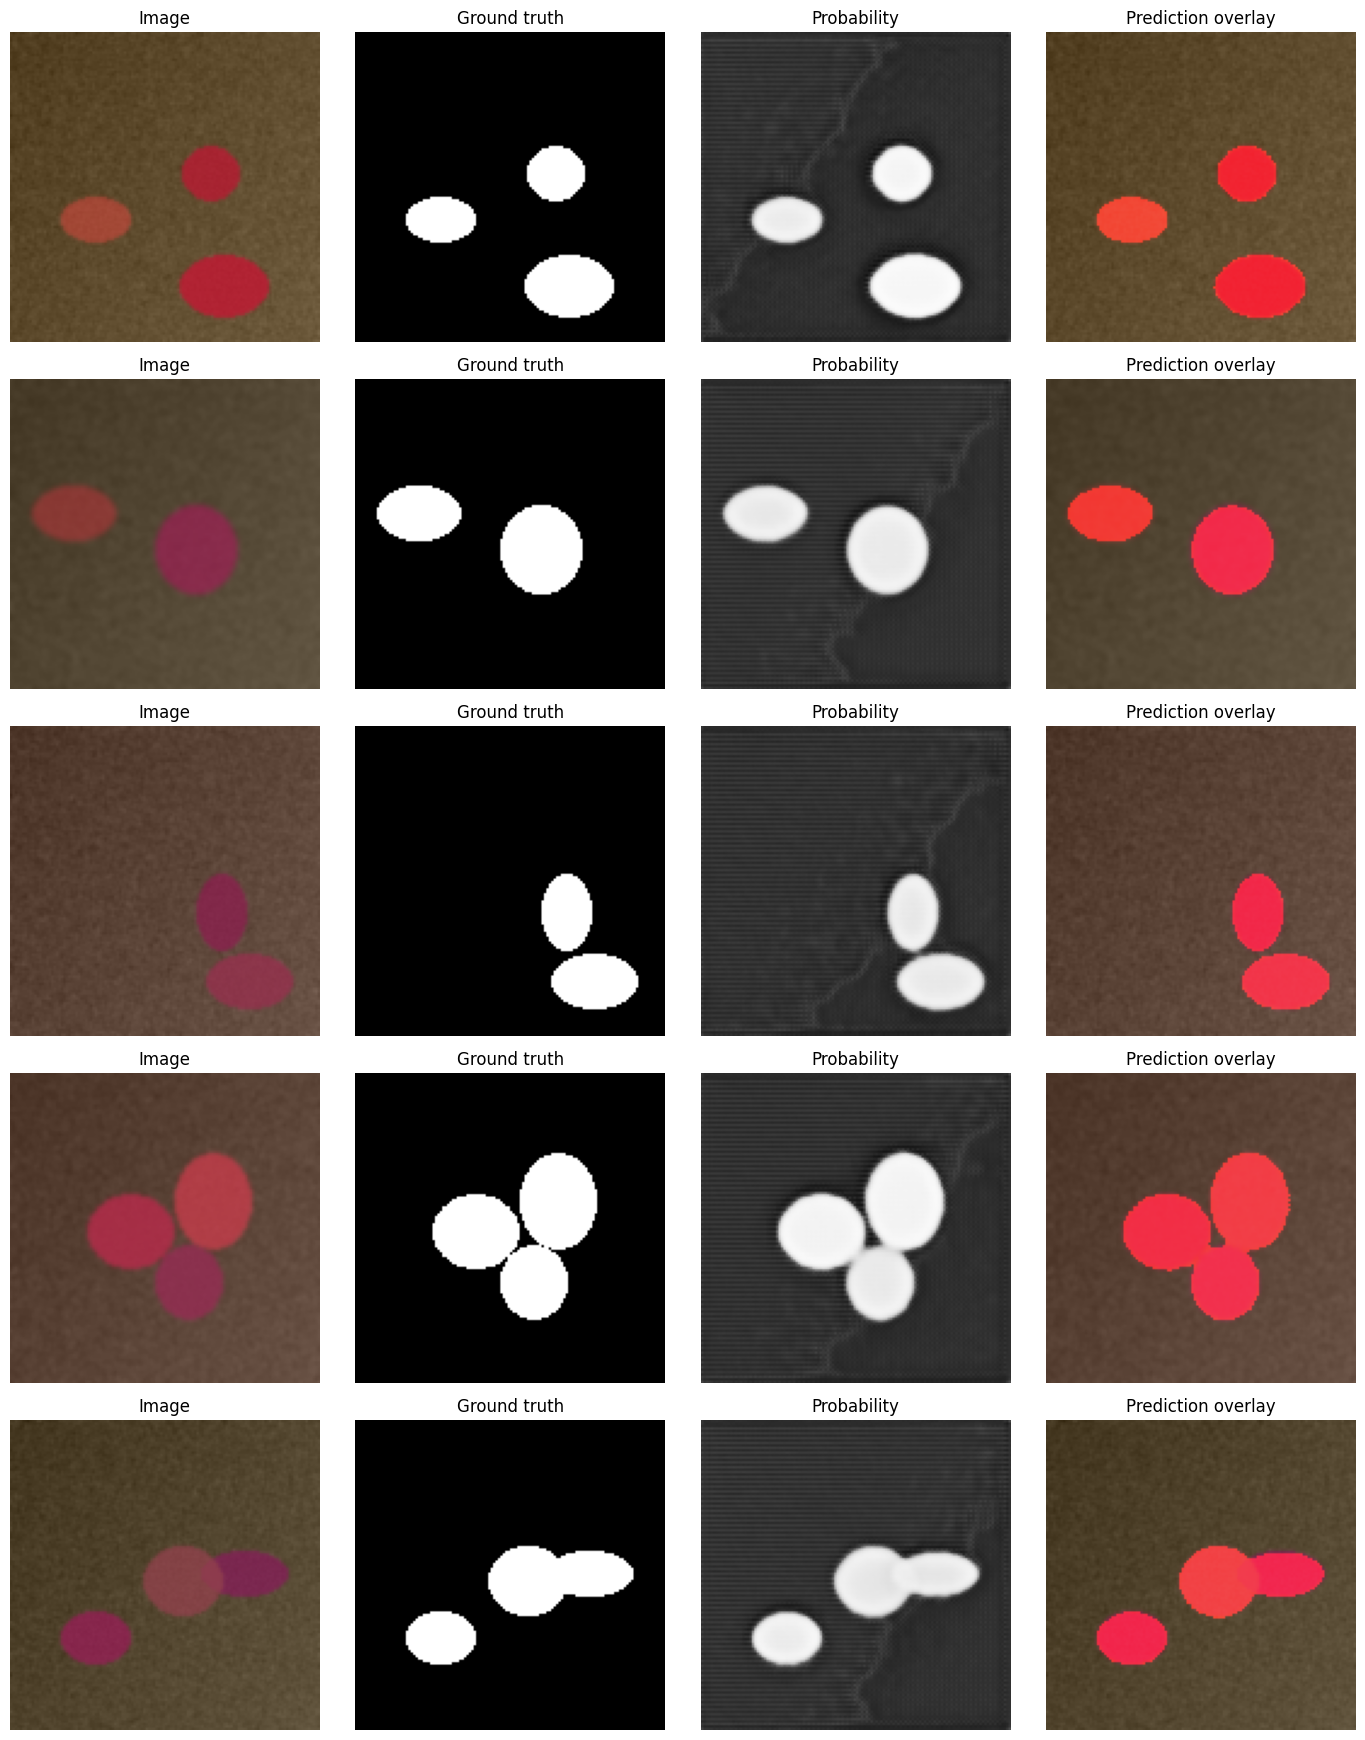

In [16]:
def show_predictions(model, dataset, count=5, threshold=0.5):
    model.eval()
    count = min(count, len(dataset))
    fig, axes = plt.subplots(count, 4, figsize=(14, 3.5 * count))
    if count == 1:
        axes = np.expand_dims(axes, 0)

    with torch.no_grad():
        for row in range(count):
            image_tensor, mask_tensor = dataset[row]
            logits = model(image_tensor.unsqueeze(0).to(DEVICE))
            probability = torch.sigmoid(logits)[0, 0].cpu().numpy()
            prediction = (probability >= threshold).astype(np.float32)
            image = image_tensor.permute(1, 2, 0).numpy()
            overlay = image.copy()
            overlay[..., 0] = np.maximum(overlay[..., 0], prediction * 0.95)

            axes[row, 0].imshow(image); axes[row, 0].set_title("Image")
            axes[row, 1].imshow(mask_tensor[0], cmap="gray"); axes[row, 1].set_title("Ground truth")
            axes[row, 2].imshow(probability, cmap="gray", vmin=0, vmax=1); axes[row, 2].set_title("Probability")
            axes[row, 3].imshow(overlay); axes[row, 3].set_title("Prediction overlay")
            for col in range(4): axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, count=5, threshold=CONFIG["threshold"])

In [17]:
def per_image_evaluation(model, dataset, threshold=0.5):
    model.eval()
    rows = []
    with torch.no_grad():
        for index in range(len(dataset)):
            image, mask = dataset[index]
            logits = model(image.unsqueeze(0).to(DEVICE))
            metrics = calculate_metrics(logits.cpu(), mask.unsqueeze(0), threshold)
            metrics["index"] = index
            metrics["mask_fraction"] = float(mask.mean().item())
            rows.append(metrics)
    return pd.DataFrame(rows).sort_values("dice").reset_index(drop=True)

per_image_results = per_image_evaluation(model, test_dataset, CONFIG["threshold"])
per_image_results.head(10)

,dice,iou,precision,recall,pixel_accuracy,index,mask_fraction
0,0.438970,0.281205,0.281205,1.000000,0.816528,18,0.071777
1,0.660488,0.493081,0.493841,0.996892,0.859131,22,0.137451
2,0.897544,0.814131,0.998896,0.814865,0.974792,11,0.135498
3,0.956256,0.916179,0.916179,1.000000,0.997375,19,0.028687
4,0.972292,0.946078,0.946078,1.000000,0.991943,13,0.141357
5,0.975410,0.952000,0.954545,0.997207,0.997803,21,0.043701
6,0.975550,0.952266,0.952648,0.999579,0.992737,5,0.144958
7,0.977354,0.955711,0.956157,0.999512,0.994202,16,0.125183
8,0.978703,0.958294,0.958294,1.000000,0.997314,7,0.061707
9,0.978979,0.958824,0.968143,0.990061,0.995300,23,0.110535


## 12. Save, reload, and run inference

In [18]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "pytorch_version": torch.__version__,
}
torch.save(checkpoint, MODEL_PATH)
print("Saved:", MODEL_PATH.resolve())

reloaded_model = UNet(base_channels=CONFIG["base_channels"]).to(DEVICE)
loaded = torch.load(MODEL_PATH, map_location=DEVICE)
reloaded_model.load_state_dict(loaded["model_state_dict"])
reloaded_model.eval()
print("Reloaded successfully.")

Saved: /content/unet_medical_segmentation.pt


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch.torch_version.TorchVersion was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])` or the `torch.serialization.safe_globals([torch.torch_version.TorchVersion])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load 

In [ ]:
def predict_mask(model, image_path: str, image_size: int, threshold: float = 0.5):
    image = Image.open(image_path).convert("RGB").resize((image_size, image_size))
    image_array = np.asarray(image, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(image_array).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        probability = torch.sigmoid(model(tensor))[0, 0].cpu().numpy()

    prediction = (probability >= threshold).astype(np.uint8)
    return image_array, probability, prediction

example_image, example_probability, example_prediction = predict_mask(
    reloaded_model, test_df.iloc[0]["image_path"], CONFIG["image_size"], CONFIG["threshold"]
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(example_image); axes[0].set_title("Input")
axes[1].imshow(example_probability, cmap="gray", vmin=0, vmax=1); axes[1].set_title("Probability")
axes[2].imshow(example_prediction, cmap="gray"); axes[2].set_title("Mask")
for axis in axes: axis.axis("off")
plt.tight_layout(); plt.show()

## 13. Using a real dataset

Organize paired files as:

```text
data/
├── images/
│   ├── sample_001.jpg
│   └── sample_002.jpg
└── masks/
    ├── sample_001.png
    └── sample_002.png
```

Then replace synthetic metadata generation with a dataframe containing matching image and mask paths.

For medical data, split at the **patient level**, not merely the image level, to reduce leakage.

## 14. Responsible deployment

A real clinical system requires data governance, de-identification, external validation, calibration, subgroup analysis, uncertainty estimation, drift monitoring, audit logs, secure access controls, human review, and applicable regulatory processes.

Synthetic performance is evidence that the pipeline runs—not evidence of clinical validity.

## 15. Portfolio summary

Built an end-to-end medical image segmentation pipeline in PyTorch using a custom U-Net architecture. Generated paired synthetic medical-style images and masks, implemented paired augmentation and data loaders, optimized a combined Dice and binary cross-entropy loss, and evaluated predictions using Dice, IoU, precision, recall, and pixel accuracy. Added checkpointing, inference, prediction overlays, and per-image error analysis.

### Resume bullets

- Developed a PyTorch U-Net for pixel-level segmentation of medical regions of interest.
- Implemented custom paired image-mask augmentation, loss functions, training, validation, and testing.
- Evaluated model quality with Dice, IoU, precision, recall, and pixel accuracy.
- Created visual and per-image error analysis to identify segmentation failure modes.
- Packaged the workflow as a reproducible, Python 3.8-compatible Jupyter notebook.

## 16. Interview questions

**Why can accuracy be misleading?**  
Background pixels may dominate, allowing high accuracy while the model misses the clinically important foreground.

**Why combine BCE and Dice loss?**  
BCE supplies stable pixel-level supervision, while Dice directly optimizes overlap.

**Why are skip connections important?**  
They preserve high-resolution localization information that would otherwise be lost during downsampling.

**Why split by patient?**  
Images from one patient can be highly correlated. Image-level splitting may leak patient-specific information into validation or test sets.

**What should be improved next?**  
Train on a governed public dataset, compare U-Net++/DeepLabV3+/SegFormer, use cross-validation, estimate uncertainty, and perform external validation.

## Conclusion

This notebook demonstrates a complete segmentation workflow suitable for a machine-learning portfolio. It is self-contained, runnable on CPU or GPU, and designed so the synthetic dataset can be replaced with a real public medical segmentation dataset.